# Détection de fraude

Ce notebook couvre l'import des librairies, le chargement de `fraudTest.csv`, l'exploration des données, le nettoyage, le préprocessing, l'entraînement, l'évaluation et la sauvegarde du pipeline dans `models/model.joblib`.

> Le jeu étant très déséquilibré, l'évaluation privilégie la **PR-AUC**, le rappel, la précision et le F1. Le seuil de décision est choisi sur un jeu de validation séparé, puis mesuré une seule fois sur le jeu de test.

## 1. Import des librairies et configuration

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import metrics
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", context="notebook")

## 2. Chargement du CSV

In [2]:
df = pd.read_csv("../data/raw/fraudTest.csv")
df.head(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [3]:
df.shape

(555719, 23)

## 3. EDA — exploration des données

In [4]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [5]:
display(pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "val_manquantes": df.isna().sum(),
    "tx_manquant_%": (df.isna().mean() * 100).round(3),
    "n_uniques": df.nunique(dropna=False),
}).sort_values("tx_manquant_%", ascending=False))

,dtype,val_manquantes,tx_manquant_%,n_uniques
Unnamed: 0,int64,0,0.0,555719
zip,int64,0,0.0,912
merch_long,float64,0,0.0,551770
merch_lat,float64,0,0.0,546490
unix_time,int64,0,0.0,544760
trans_num,str,0,0.0,555719
dob,str,0,0.0,910
job,str,0,0.0,478
city_pop,int64,0,0.0,835
long,float64,0,0.0,910


In [6]:
class_counts = df["is_fraud"].value_counts().sort_index()
class_rates = (df["is_fraud"].value_counts(normalize=True).sort_index() * 100)
display(pd.DataFrame({"nombre": class_counts, "pourcentage": class_rates.round(4)}).rename(index={0: "légitime", 1: "fraude"}))

,nombre,pourcentage
is_fraud,,
légitime,553574,99.614
fraude,2145,0.386


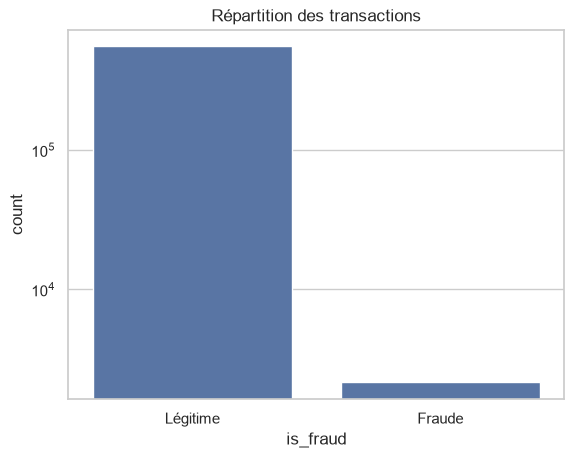

In [7]:
sns.countplot(data=df, x="is_fraud")
plt.yscale("log")
plt.title("Répartition des transactions")
plt.xticks([0, 1], ["Légitime", "Fraude"])
plt.show()

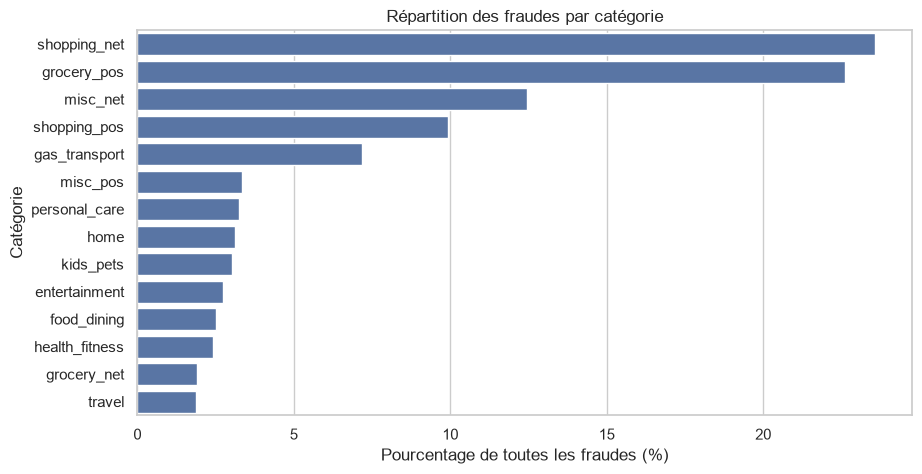

In [8]:
fraud_categories = (
    df[df["is_fraud"] == 1]["category"]
    .value_counts(normalize=True)
    .mul(100)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=fraud_categories.values,
    y=fraud_categories.index
)

plt.title("Répartition des fraudes par catégorie")
plt.xlabel("Pourcentage de toutes les fraudes (%)")
plt.ylabel("Catégorie")
plt.show()

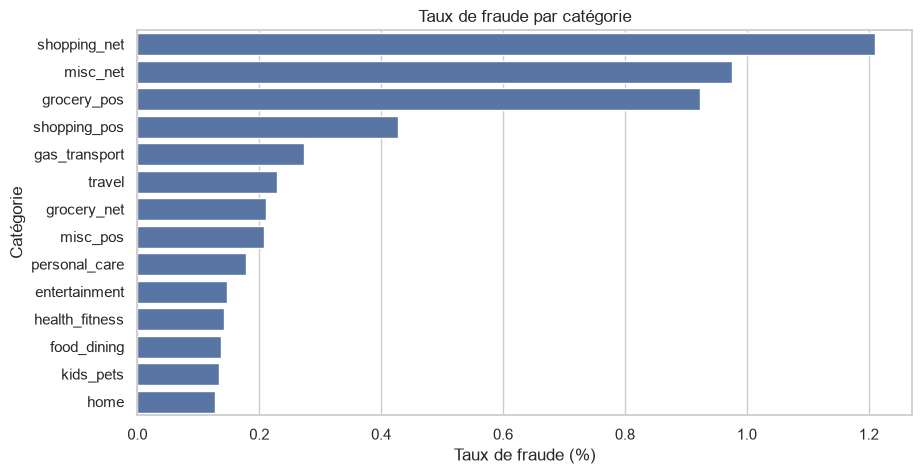

In [9]:
fraud_by_category = (
    df.groupby("category")["is_fraud"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=fraud_by_category.values,
    y=fraud_by_category.index
)

plt.title("Taux de fraude par catégorie")
plt.xlabel("Taux de fraude (%)")
plt.ylabel("Catégorie")
plt.show()

## 4. Nettoyage

In [10]:
df_clean = df.copy()

#### Suppression de la colonne inutile et des doublons

In [11]:
df_clean = df_clean.drop(columns=["Unnamed: 0"], errors="ignore")
df_clean.shape

(555719, 22)

#### Conversion des dates

In [12]:
df_clean["trans_date_trans_time"] = pd.to_datetime(df_clean["trans_date_trans_time"])
df_clean["dob"] = pd.to_datetime(df_clean["dob"])

## 5. Préprocessing et séparation des données

### Choix et séparation des variables

In [13]:
numeric_features = [
    "amt", "zip", "lat", "long", "city_pop", "unix_time", "merch_lat", "merch_long"
]
categorical_features = ["category", "gender", "state"]
feature_columns = numeric_features + categorical_features
target_column = "is_fraud"

X = df_clean[feature_columns].copy()
y = df_clean[target_column].copy()

In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

### Pipeline

In [15]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])


classifier = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=258,
    eval_metric="aucpr",
    random_state=42
)
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", classifier),
])
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, 

## 6. Entraînement du modèle

In [16]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['amt','zip','lat',...,'category','gender','state']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all rem

## 7. Choix du seuil sur la validation

In [17]:
valid_proba = pipeline.predict_proba(X_valid)[:, 1]

precision, recall, thresholds = metrics.precision_recall_curve(y_valid, valid_proba)

f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1])

best_index = f1_scores.argmax()
best_threshold = thresholds[best_index]

print("Seuil retenu :", round(best_threshold, 4))
print("F1 validation :", round(f1_scores[best_index], 4))
print("PR-AUC validation :", round(metrics.average_precision_score(y_valid, valid_proba), 4))

Seuil retenu : 0.9864
F1 validation : 0.7901
PR-AUC validation : 0.8547



Le seuil maximisant le F1 est attaché au pipeline sauvegardé sous l'attribut `fraud_threshold_`.

In [18]:
pipeline.fraud_threshold_ = best_threshold
pipeline.feature_columns_ = feature_columns

## 8. Évaluation finale sur le jeu de test

In [19]:
test_proba = pipeline.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

print("PR-AUC :", round(metrics.average_precision_score(y_test, test_proba), 4))
print("ROC-AUC :", round(metrics.roc_auc_score(y_test, test_proba), 4))
print("F1 :", round(metrics.f1_score(y_test, test_pred), 4))
print("Seuil :", round(best_threshold, 4))

print(metrics.classification_report(
    y_test,
    test_pred,
    target_names=["légitime", "fraude"],
    zero_division=0
))

PR-AUC : 0.8358
ROC-AUC : 0.9975
F1 : 0.7664
Seuil : 0.9864
              precision    recall  f1-score   support

    légitime       1.00      1.00      1.00     83036
      fraude       0.84      0.71      0.77       322

    accuracy                           1.00     83358
   macro avg       0.92      0.85      0.88     83358
weighted avg       1.00      1.00      1.00     83358



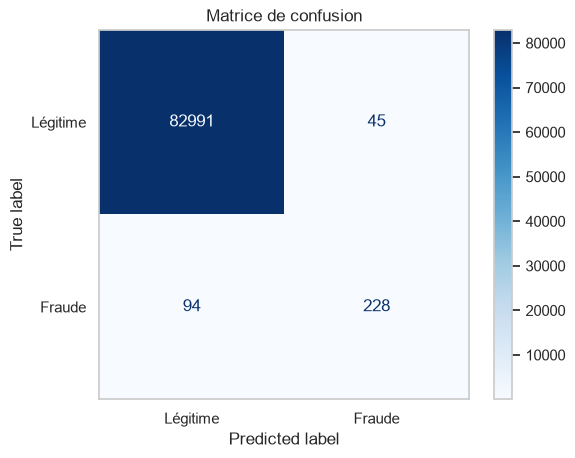

In [20]:
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    display_labels=["Légitime", "Fraude"],
    cmap="Blues"
)

plt.grid(False)
plt.title("Matrice de confusion")
plt.show()

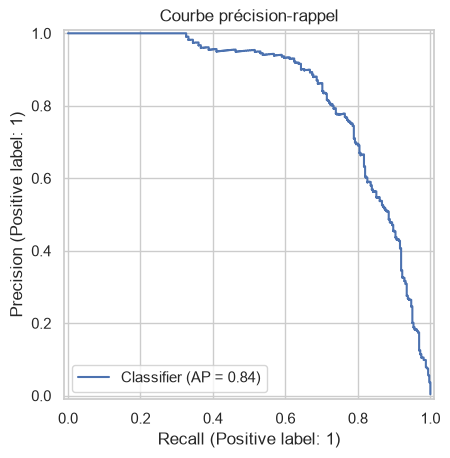

In [21]:
metrics.PrecisionRecallDisplay.from_predictions(
    y_test,
    test_proba
)

plt.title("Courbe précision-rappel")
plt.show()

## 9. Sauvegarde et contrôle du pipeline

Le fichier contient le préprocessing, le classifieur, le seuil sélectionné (`fraud_threshold_`) et la liste des colonnes attendues (`feature_columns_`).

pour permettre au modèle de detecter plus de fraude, j'ai décidé de baisser le seuil : 

In [25]:
best_threshold = 0.9722
pipeline.fraud_threshold_ = best_threshold

print("Nouveau seuil :", pipeline.fraud_threshold_)

Nouveau seuil : 0.9722


In [23]:
MODEL_FILE = "../models/model.joblib"

In [24]:
joblib.dump(pipeline, MODEL_FILE)

print("Pipeline sauvegardé :", MODEL_FILE)

Pipeline sauvegardé : ../models/model.joblib
